In [7]:
# Imports 
import os, json, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [8]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os
os.listdir("/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/processed")

['y_labels.npy', 'features_combined.csv', 'X_features.npy', 'label_map.json']

In [11]:
# Load processed data
DATA_DIR   = Path('/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/processed')
OUTPUT_DIR = Path('/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/model_output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

X_raw = np.load(DATA_DIR / 'X_features.npy')   # (9938, 378)
y_raw = np.load(DATA_DIR / 'y_labels.npy')      # (9938,)

with open(DATA_DIR / 'label_map.json') as f:
    lm           = json.load(f)
    label_to_int = lm['label_to_int']
    int_to_label = {int(k): v for k, v in lm['int_to_label'].items()}

NUM_CLASSES = len(label_to_int)
FEATURE_DIM = X_raw.shape[1]          # 378
SPECTRAL_DIM = 128                    # mel features (feat_0 to feat_127)
TEMPORAL_DIM = FEATURE_DIM - SPECTRAL_DIM  # 250 — MFCC + delta + prosodic

assert not np.isnan(X_raw).any()
assert not np.isinf(X_raw).any()

print(f'Samples      : {len(X_raw)}')
print(f'Feature dim  : {FEATURE_DIM}  (spectral={SPECTRAL_DIM}, temporal={TEMPORAL_DIM})')
print(f'Classes      : {NUM_CLASSES}  → {int_to_label}')
print('Data integrity: OK')

Samples      : 9938
Feature dim  : 378  (spectral=128, temporal=250)
Classes      : 6  → {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad'}
Data integrity: OK


In [12]:
# Train / Val / Test split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=SEED, stratify=y_raw)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}')

for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = np.bincount(y, minlength=NUM_CLASSES)
    print(f'  {name}: ' + '  '.join(f'{int_to_label[i]}={c}' for i,c in enumerate(counts)))

Train: 6956  Val: 1491  Test: 1491
  Train: angry=1158  disgust=1159  fear=1158  happy=1158  neutral=1164  sad=1159
  Val: angry=248  disgust=248  fear=249  happy=248  neutral=250  sad=248
  Test: angry=249  disgust=248  fear=248  happy=249  neutral=249  sad=248


In [13]:
#  Normalize (fit on train only)
import joblib
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
print(f'Scaler fitted on {len(X_train)} samples. Saved.')

Scaler fitted on 6956 samples. Saved.


In [14]:
# Dataset with feature-group masking augmentation
#
# Feature groups in our 378-dim vector:
#   [0:128]   mel-spectrogram means  → spectral stream
#   [128:168] MFCC mean (40 coeff)
#   [168:208] MFCC std
#   [208:248] delta MFCC mean
#   [248:288] delta MFCC std
#   [288:378] prosodic (RMS, ZCR, centroid, bandwidth, rolloff)
#
# During training: add noise + randomly zero out entire feature groups.
# This forces the model to learn from multiple modalities, not rely on one.

class EmotionDataset(Dataset):
    def __init__(self, X, y, augment=False, noise_std=0.02, mask_prob=0.10):
        self.X         = torch.tensor(X, dtype=torch.float32)
        self.y         = torch.tensor(y, dtype=torch.long)
        self.augment   = augment
        self.noise_std = noise_std
        self.mask_prob = mask_prob
        n = X.shape[1]
        self.groups = [(0,128),(128,168),(168,208),(208,248),(248,288),(288,n)]

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            x = x + torch.randn_like(x) * self.noise_std
            for s, e in self.groups:
                if torch.rand(1).item() < self.mask_prob:
                    x[s:e] = 0.0
        return x[:SPECTRAL_DIM], x[SPECTRAL_DIM:], self.y[idx]


def make_sampler(y):
    counts  = np.bincount(y, minlength=NUM_CLASSES)
    weights = 1.0 / (counts + 1e-8)
    return WeightedRandomSampler(
        torch.tensor(weights[y], dtype=torch.float32),
        num_samples=len(y), replacement=True)


BATCH_SIZE = 64

train_ds = EmotionDataset(X_train_sc, y_train, augment=True)
val_ds   = EmotionDataset(X_val_sc,   y_val,   augment=False)
test_ds  = EmotionDataset(X_test_sc,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=make_sampler(y_train),
                          num_workers=2, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

xs, xt, lb = train_ds[0]
print(f'Spectral: {xs.shape}  Temporal: {xt.shape}  Label: {int_to_label[lb.item()]}')
print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Spectral: torch.Size([128])  Temporal: torch.Size([250])  Label: sad
Train batches: 109  Val: 24  Test: 24


#### We are building four different model architectures
    1. DSCANet          — dual-stream cross-attention (novel)
    2. BiLSTMAttention  — sequential temporal baseline
    3. CNNAttention     — spectral CNN baseline
    4. TransformerSER   — pure transformer baseline

In [15]:
# DS-CANet: Dual-Stream Cross-Attention Network
#
# Architecture overview:
#   Stream A: Linear projection → multi-head self-attention    (spectral)
#   Stream B: BiLSTM → Linear projection → self-attention      (temporal)
#   Cross-attention bridge: A queries B AND B queries A (bidirectional)
#   Gated fusion: learned sigmoid gate combines both enriched streams
#   Emotion-aware pooling: attention-weighted aggregation
#   Classifier: Linear → Dropout → output logits

# Emotion-Aware Pooling 
class EmotionAwarePooling(nn.Module):
    """Attention-weighted mean over the sequence dimension."""
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Linear(d_model, 1)
    def forward(self, x):                          # x: (B, T, d)
        w = F.softmax(self.score(x), dim=1)        # (B, T, 1)
        return (w * x).sum(dim=1)                  # (B, d)


# Gated Fusion 
class GatedFusion(nn.Module):
    """Learned sigmoid gate: output = z*a + (1-z)*b."""
    def __init__(self, d_model):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(d_model*2, d_model), nn.Sigmoid())
        self.norm = nn.LayerNorm(d_model)
    def forward(self, a, b):
        z = self.gate(torch.cat([a, b], dim=-1))
        return self.norm(z*a + (1-z)*b)


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1: DS-CANet (Dual-Stream Cross-Attention Network)
# novel architecture — academic contribution
# ─────────────────────────────────────────────────────────────────────────────
class DSCANet(nn.Module):
    def __init__(self, spectral_dim, temporal_dim, d_model=64,
                 num_heads=4, num_classes=6, dropout=0.5,
                 lstm_hidden=64, lstm_layers=2, temporal_steps=10):
        super().__init__()

        # Stream A — spectral (mel features)
        self.spec_proj = nn.Sequential(
            nn.Linear(spectral_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.spec_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.spec_norm = nn.LayerNorm(d_model)

        # Stream B — temporal (MFCC + prosodic)
        assert temporal_dim % temporal_steps == 0
        step_dim = temporal_dim // temporal_steps
        self.step_proj  = nn.Linear(step_dim, lstm_hidden)
        self.bilstm     = nn.LSTM(lstm_hidden, lstm_hidden, lstm_layers,
                                  batch_first=True, bidirectional=True,
                                  dropout=dropout if lstm_layers>1 else 0)
        self.lstm_proj  = nn.Sequential(
            nn.Linear(2*lstm_hidden, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.temp_attn  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.temp_norm  = nn.LayerNorm(d_model)
        self.temporal_steps = temporal_steps

        # Cross-stream attention (the novel part)
        self.cross_a2b  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_b2a  = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.ca_norm_a  = nn.LayerNorm(d_model)
        self.ca_norm_b  = nn.LayerNorm(d_model)
        self.ffn_a = nn.Sequential(nn.Linear(d_model,d_model*2),nn.GELU(),nn.Dropout(dropout),nn.Linear(d_model*2,d_model))
        self.ffn_b = nn.Sequential(nn.Linear(d_model,d_model*2),nn.GELU(),nn.Dropout(dropout),nn.Linear(d_model*2,d_model))
        self.ffn_norm_a = nn.LayerNorm(d_model)
        self.ffn_norm_b = nn.LayerNorm(d_model)

        self.pool_a  = EmotionAwarePooling(d_model)
        self.pool_b  = EmotionAwarePooling(d_model)
        self.fusion  = GatedFusion(d_model)
        self.drop    = nn.Dropout(dropout)
        self.head    = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        # Stream A
        a = self.spec_proj(x_spec).unsqueeze(1)          # (B,1,d)
        ao, _ = self.spec_attn(a, a, a)
        a = self.spec_norm(a + self.drop(ao))            # (B,1,d)

        # Stream B
        B = x_temp.size(0)
        b = x_temp.view(B, self.temporal_steps, -1)
        b = self.step_proj(b)
        b, _ = self.bilstm(b)
        b = self.lstm_proj(b)                            # (B,T,d)
        bo, _ = self.temp_attn(b, b, b)
        b = self.temp_norm(b + self.drop(bo))

        # Cross-attention: A queries B
        ao2, _ = self.cross_a2b(query=a, key=b, value=b)
        a = self.ca_norm_a(a + self.drop(ao2))
        a = self.ffn_norm_a(a + self.ffn_a(a))

        # Cross-attention: B queries A
        bo2, _ = self.cross_b2a(query=b, key=a, value=a)
        b = self.ca_norm_b(b + self.drop(bo2))
        b = self.ffn_norm_b(b + self.ffn_b(b))

        a = self.pool_a(a)    # (B,d)
        b = self.pool_b(b)    # (B,d)
        return self.head(self.fusion(a, b))

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2: BiLSTM-Attention
# Classic sequential model — strong temporal baseline
# ─────────────────────────────────────────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    def __init__(self, input_dim, d_model=64, num_heads=4,
                 num_classes=6, dropout=0.5, lstm_hidden=64,
                 lstm_layers=2, temporal_steps=10):
        super().__init__()
        assert input_dim % temporal_steps == 0
        self.temporal_steps = temporal_steps
        step_dim = input_dim // temporal_steps
        self.step_proj = nn.Linear(step_dim, lstm_hidden)
        self.bilstm    = nn.LSTM(lstm_hidden, lstm_hidden, lstm_layers,
                                 batch_first=True, bidirectional=True,
                                 dropout=dropout if lstm_layers>1 else 0)
        self.proj = nn.Sequential(
            nn.Linear(2*lstm_hidden, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.pool = EmotionAwarePooling(d_model)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        # Uses full feature vector (spec + temp concatenated)
        x = torch.cat([x_spec, x_temp], dim=-1)         # (B, 378)
        B = x.size(0)
        x = x.view(B, self.temporal_steps, -1)
        x = self.step_proj(x)
        x, _ = self.bilstm(x)
        x = self.proj(x)
        ao, _ = self.attn(x, x, x)
        x = self.norm(x + self.drop(ao))
        return self.head(self.pool(x))

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3: CNN-Attention
# Spectral-focused model — treats features as 1D signal
# ─────────────────────────────────────────────────────────────────────────────
class CNNAttention(nn.Module):
    def __init__(self, input_dim, d_model=64, num_heads=4,
                 num_classes=6, dropout=0.5):
        super().__init__()
        # 3 Conv1d blocks over the feature dimension
        # input: (B, 1, input_dim) — treating feature vector as 1-channel signal
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3), nn.BatchNorm1d(32), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(64, d_model, kernel_size=3, padding=1), nn.BatchNorm1d(d_model), nn.GELU())
        # output: (B, d_model, input_dim) → transpose to (B, input_dim, d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.pool = EmotionAwarePooling(d_model)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        x = torch.cat([x_spec, x_temp], dim=-1)         # (B, 378)
        x = x.unsqueeze(1)                              # (B, 1, 378)
        x = self.cnn(x)                                 # (B, d_model, 378)
        x = x.transpose(1, 2)                           # (B, 378, d_model)
        ao, _ = self.attn(x, x, x)
        x = self.norm(x + self.drop(ao))
        return self.head(self.pool(x))

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4: Transformer
# Pure multi-head self-attention encoder — modern baseline
# ─────────────────────────────────────────────────────────────────────────────
class TransformerSER(nn.Module):
    def __init__(self, input_dim, d_model=64, num_heads=4,
                 num_classes=6, dropout=0.5, num_layers=3,
                 chunk_size=14):
        super().__init__()
        # Split 378-dim vector into chunks → sequence of tokens
        # 378 / 14 = 27 tokens, each of dim 14 → project to d_model
        assert input_dim % chunk_size == 0, f'{input_dim} not divisible by {chunk_size}'
        self.chunk_size = chunk_size
        self.n_tokens   = input_dim // chunk_size
        self.tok_proj   = nn.Linear(chunk_size, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pool     = EmotionAwarePooling(d_model)
        self.head     = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        x = torch.cat([x_spec, x_temp], dim=-1)         # (B, 378)
        B = x.size(0)
        x = x.view(B, self.n_tokens, self.chunk_size)   # (B, 27, 14)
        x = self.tok_proj(x)                            # (B, 27, d_model)
        x = self.encoder(x)                             # (B, 27, d_model)
        return self.head(self.pool(x))

In [19]:
# Hyperparameters + Focal Loss
#
# Focal Loss: downweights easy correct predictions,
# upweights hard wrong predictions (disgust, fear).
# gamma=2.0 is the standard value from the original paper.

D_MODEL      = 64
NUM_HEADS    = 4
LSTM_HIDDEN  = 64
LSTM_LAYERS  = 2
DROPOUT      = 0.5
LR           = 2e-4
WEIGHT_DECAY = 5e-4
EPOCHS       = 100
PATIENCE     = 15
WARMUP_EPOCHS = 5


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.1):
        super().__init__()
        self.gamma            = gamma
        self.weight           = weight
        self.label_smoothing  = label_smoothing

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, weight=self.weight,
                              label_smoothing=self.label_smoothing, reduction='none')
        pt  = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


# Class weights (balanced — all ~1.0 since your dataset is already balanced)
class_counts  = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
cw_tensor     = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = FocalLoss(gamma=2.0, weight=cw_tensor, label_smoothing=0.1)

print('Loss: FocalLoss(gamma=2.0) + class weights + label_smoothing=0.1')
print(f'Hyperparams: d_model={D_MODEL}, dropout={DROPOUT}, lr={LR}')

Loss: FocalLoss(gamma=2.0) + class weights + label_smoothing=0.1
Hyperparams: d_model=64, dropout=0.5, lr=0.0002


In [20]:
# Training utilities

def mixup_batch(xs, xt, labels, num_classes, alpha=0.3):
    lam  = max(np.random.beta(alpha, alpha), 1 - np.random.beta(alpha, alpha))
    perm = torch.randperm(xs.size(0), device=xs.device)
    xs_m = lam*xs + (1-lam)*xs[perm]
    xt_m = lam*xt + (1-lam)*xt[perm]
    y_oh = F.one_hot(labels, num_classes).float()
    y_m  = lam*y_oh + (1-lam)*y_oh[perm]
    return xs_m, xt_m, y_m


def train_one_epoch(model, loader, optimizer, criterion, device,
                    num_classes, mixup_prob=0.5, mixup_alpha=0.3):
    model.train()
    kl  = nn.KLDivLoss(reduction='batchmean')
    tot_loss, tot_correct, tot_n = 0., 0, 0
    for xs, xt, labels in loader:
        xs, xt, labels = xs.to(device), xt.to(device), labels.to(device)
        optimizer.zero_grad()
        if np.random.random() < mixup_prob:
            xs_m, xt_m, y_soft = mixup_batch(xs, xt, labels, num_classes, mixup_alpha)
            logits = model(xs_m, xt_m)
            loss   = kl(F.log_softmax(logits, dim=-1), y_soft)
        else:
            logits = model(xs, xt)
            loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        preds = logits.argmax(-1)
        tot_correct += (preds == labels).sum().item()
        tot_loss    += loss.item() * len(labels)
        tot_n       += len(labels)
    return tot_loss/tot_n, tot_correct/tot_n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    tot_loss, tot_correct, tot_n = 0., 0, 0
    all_preds, all_labels = [], []
    for xs, xt, labels in loader:
        xs, xt, labels = xs.to(device), xt.to(device), labels.to(device)
        logits = model(xs, xt)
        loss   = criterion(logits, labels)
        preds  = logits.argmax(-1)
        tot_correct += (preds == labels).sum().item()
        tot_loss    += loss.item() * len(labels)
        tot_n       += len(labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    per_class  = [(all_preds[all_labels==c]==c).mean()
                  for c in range(NUM_CLASSES) if (all_labels==c).sum()>0]
    return tot_loss/tot_n, tot_correct/tot_n, np.mean(per_class), all_preds, all_labels


def make_scheduler(optimizer):
    warmup = LambdaLR(optimizer, lambda e: min(1.0, (e+1)/WARMUP_EPOCHS))
    cosine = CosineAnnealingLR(optimizer, T_max=EPOCHS-WARMUP_EPOCHS, eta_min=1e-6)
    return SequentialLR(optimizer, [warmup, cosine], milestones=[WARMUP_EPOCHS])


def train_model(model, name):
    """Full training loop. Returns best state dict and val UA history."""
    opt       = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched     = make_scheduler(opt)
    best_ua   = 0.0
    best_wts  = copy.deepcopy(model.state_dict())
    patience  = 0
    history   = {'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[],'val_ua':[]}
    swa_ckpts = []
    t0        = time.time()

    print(f'\n{"─"*70}')
    print(f'Training: {name}')
    print(f'{"─"*70}')
    print(f'{"Ep":>4} | {"TrLoss":>8} | {"TrAcc":>7} | {"VaLoss":>8} | {"VaWA":>7} | {"VaUA":>7} | {"Gap":>6}')
    print('─'*60)

    for epoch in range(1, EPOCHS+1):
        tl, ta = train_one_epoch(model, train_loader, opt, criterion,
                                 DEVICE, NUM_CLASSES)
        vl, va, vu, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        sched.step()

        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        history['val_ua'].append(vu)

        # Collect SWA checkpoints in last 10 epochs
        if epoch >= EPOCHS - 10:
            swa_ckpts.append(copy.deepcopy(model.state_dict()))

        print(f'{epoch:>4} | {tl:>8.4f} | {ta:>6.2%} | {vl:>8.4f} | {va:>6.2%} | {vu:>6.2%} | {ta-va:>+5.1%}')

        if vu > best_ua:
            best_ua  = vu
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, OUTPUT_DIR / f'{name}_best.pt')
            print(f'     ↑ New best UA: {best_ua:.2%}')
            patience = 0
        else:
            patience += 1
        if patience >= PATIENCE:
            print(f'Early stop at epoch {epoch}')
            break

    # Apply SWA: average last checkpoints
    if len(swa_ckpts) >= 2:
        swa_state = copy.deepcopy(swa_ckpts[0])
        for key in swa_state:
            for ck in swa_ckpts[1:]:
                swa_state[key] = swa_state[key] + ck[key]
            swa_state[key] = swa_state[key] / len(swa_ckpts)
        model.load_state_dict(swa_state)
        _, _, swa_ua, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        if swa_ua > best_ua:
            best_ua  = swa_ua
            best_wts = swa_state
            print(f'SWA improved val UA to {swa_ua:.2%}')

    model.load_state_dict(best_wts)
    print(f'Done in {(time.time()-t0)/60:.1f} min  |  Best Val UA: {best_ua:.2%}')
    return model, best_ua, history


print('All training utilities defined.')

All training utilities defined.


In [21]:
# Instantiate and dry-run all 4 models to verify correctness and count parameters.
models_config = {
    'DSCANet': DSCANet(
        spectral_dim=SPECTRAL_DIM, temporal_dim=TEMPORAL_DIM,
        d_model=D_MODEL, num_heads=NUM_HEADS, num_classes=NUM_CLASSES,
        dropout=DROPOUT, lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS,
        temporal_steps=10),
    'BiLSTM_Attn': BiLSTMAttention(
        input_dim=FEATURE_DIM, d_model=D_MODEL, num_heads=NUM_HEADS,
        num_classes=NUM_CLASSES, dropout=DROPOUT, lstm_hidden=LSTM_HIDDEN,
        lstm_layers=LSTM_LAYERS, temporal_steps=27),  # 378/27=14 ✓
    'CNN_Attn': CNNAttention(
        input_dim=FEATURE_DIM, d_model=D_MODEL, num_heads=NUM_HEADS,
        num_classes=NUM_CLASSES, dropout=DROPOUT),
    'Transformer': TransformerSER(
        input_dim=FEATURE_DIM, d_model=D_MODEL, num_heads=NUM_HEADS,
        num_classes=NUM_CLASSES, dropout=DROPOUT,
        num_layers=3, chunk_size=14),  # 378/14=27 tokens ✓
}

# Move all to device and dry-run
dummy_spec = torch.randn(4, SPECTRAL_DIM).to(DEVICE)
dummy_temp = torch.randn(4, TEMPORAL_DIM).to(DEVICE)

print(f'{"Model":<16} {"Params":>10}  {"Output shape"}')
print('─'*42)
for name, m in models_config.items():
    m = m.to(DEVICE)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    out    = m(dummy_spec, dummy_temp)
    print(f'{name:<16} {params:>10,}  {tuple(out.shape)}')
    models_config[name] = m  # update in-place after .to(DEVICE)

print('\nAll models OK.')

/tmp/ipykernel_3954/2764767033.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Model                Params  Output shape
──────────────────────────────────────────
DSCANet             295,592  (4, 6)
BiLSTM_Attn         194,343  (4, 6)
CNN_Attn             42,343  (4, 6)
Transformer         153,255  (4, 6)

All models OK.


In [22]:
# Train all 4 models
#
# Each model trains independently with the same:
#   - hyperparameters
#   - data splits
#   - augmentation
#   - loss function
# Results are stored in trained_models and all_histories.

trained_models = {}
best_val_uas   = {}
all_histories  = {}

for name, model in models_config.items():
    # Reset weights for fair comparison
    def reset_weights(m):
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()
    model.apply(reset_weights)

    trained_model, best_ua, history = train_model(model, name)
    trained_models[name] = trained_model
    best_val_uas[name]   = best_ua
    all_histories[name]  = history

print('\n' + '='*45)
print('   VALIDATION UA SUMMARY')
print('='*45)
for name, ua in sorted(best_val_uas.items(), key=lambda x: -x[1]):
    bar = '█' * int(ua * 40)
    print(f'  {name:<16} {ua:.2%}  {bar}')
print('='*45)


──────────────────────────────────────────────────────────────────────
Training: DSCANet
──────────────────────────────────────────────────────────────────────
  Ep |   TrLoss |   TrAcc |   VaLoss |    VaWA |    VaUA |    Gap
────────────────────────────────────────────────────────────
   1 |   1.4189 | 19.09% |   1.1987 | 26.43% | 26.46% | -7.3%
     ↑ New best UA: 26.46%
   2 |   1.3605 | 22.14% |   1.1424 | 29.51% | 29.54% | -7.4%
     ↑ New best UA: 29.54%
   3 |   1.3529 | 27.00% |   1.0894 | 34.27% | 34.29% | -7.3%
     ↑ New best UA: 34.29%
   4 |   1.3044 | 28.94% |   1.0420 | 37.09% | 37.10% | -8.2%
     ↑ New best UA: 37.10%
   5 |   1.2401 | 31.73% |   0.9999 | 39.57% | 39.59% | -7.8%
     ↑ New best UA: 39.59%
   6 |   1.1901 | 33.55% |   0.9767 | 40.58% | 40.59% | -7.0%
     ↑ New best UA: 40.59%
   7 |   1.1859 | 35.67% |   0.9355 | 43.73% | 43.73% | -8.1%
     ↑ New best UA: 43.73%
   8 |   1.1854 | 37.06% |   0.9084 | 45.14% | 45.12% | -8.1%
     ↑ New best UA: 45.12%


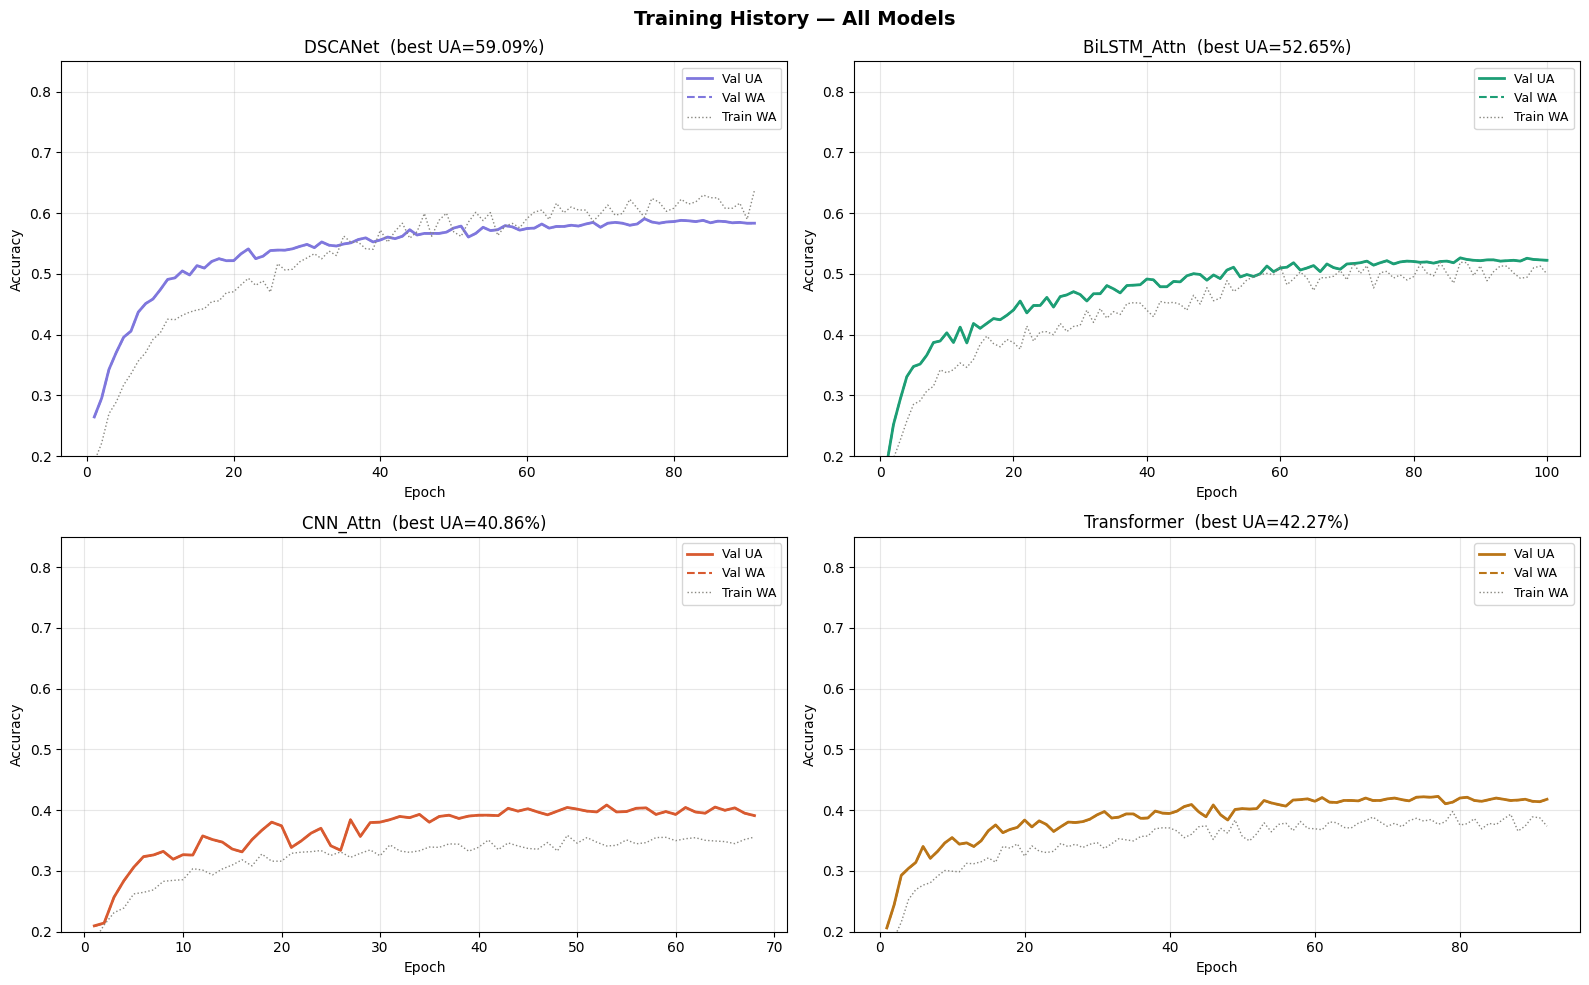

In [23]:
# Training curves for all models 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training History — All Models', fontsize=14, fontweight='bold')
colors = {'DSCANet':'#7F77DD','BiLSTM_Attn':'#1D9E75','CNN_Attn':'#D85A30','Transformer':'#BA7517'}

axes = axes.flatten()
for i, (name, h) in enumerate(all_histories.items()):
    ep = range(1, len(h['train_loss'])+1)
    ax = axes[i]
    ax.plot(ep, h['val_ua'],   color=colors[name], linewidth=2, label='Val UA')
    ax.plot(ep, h['val_acc'],  color=colors[name], linewidth=1.5, linestyle='--', label='Val WA')
    ax.plot(ep, h['train_acc'],color='#888780', linewidth=1, linestyle=':', label='Train WA')
    ax.set_title(f'{name}  (best UA={best_val_uas[name]:.2%})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(0.2, 0.85)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_models_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Full test-set evaluation for all models
print('='*65)
print(f'  {"MODEL":<18}  {"Test WA":>8}  {"Test UA":>8}  {"angry":>7}  {"sad":>6}  {"disgust":>8}')
print('─'*65)

all_test_results = {}
target_names = [int_to_label[i] for i in range(NUM_CLASSES)]

for name, model in trained_models.items():
    _, wa, ua, preds, labels = evaluate(model, test_loader, criterion, DEVICE)
    # Per-class accuracy
    per = {int_to_label[c]: (preds[labels==c]==c).mean() for c in range(NUM_CLASSES)}
    all_test_results[name] = {'wa':wa,'ua':ua,'preds':preds,'labels':labels,'per':per}
    print(f'  {name:<18}  {wa:>8.2%}  {ua:>8.2%}  {per["angry"]:>7.2%}  {per["sad"]:>6.2%}  {per["disgust"]:>8.2%}')

print('='*65)

# Identify best model for personal project
best_name = max(all_test_results, key=lambda k: all_test_results[k]['ua'])
print(f'\n→ Best model for personal project: {best_name} (UA={all_test_results[best_name]["ua"]:.2%})')

  MODEL                Test WA   Test UA    angry     sad   disgust
─────────────────────────────────────────────────────────────────
  DSCANet               60.56%    60.55%   79.92%  59.68%    44.35%
  BiLSTM_Attn           54.93%    54.92%   70.28%  64.52%    35.08%
  CNN_Attn              40.51%    40.50%   61.04%  59.27%    21.77%
  Transformer           42.72%    42.72%   66.27%  60.48%    34.68%

→ Best model for personal project: DSCANet (UA=60.55%)


In [25]:
# Detailed report for the best model 
r = all_test_results[best_name]
print(f'Detailed results for {best_name}:')
print(classification_report(r['labels'], r['preds'], target_names=target_names, digits=4))

Detailed results for DSCANet:
              precision    recall  f1-score   support

       angry     0.6862    0.7992    0.7384       249
     disgust     0.6548    0.4435    0.5288       248
        fear     0.6132    0.5242    0.5652       248
       happy     0.5922    0.6064    0.5992       249
     neutral     0.5872    0.6627    0.6226       249
         sad     0.5193    0.5968    0.5553       248

    accuracy                         0.6056      1491
   macro avg     0.6088    0.6055    0.6016      1491
weighted avg     0.6088    0.6056    0.6017      1491



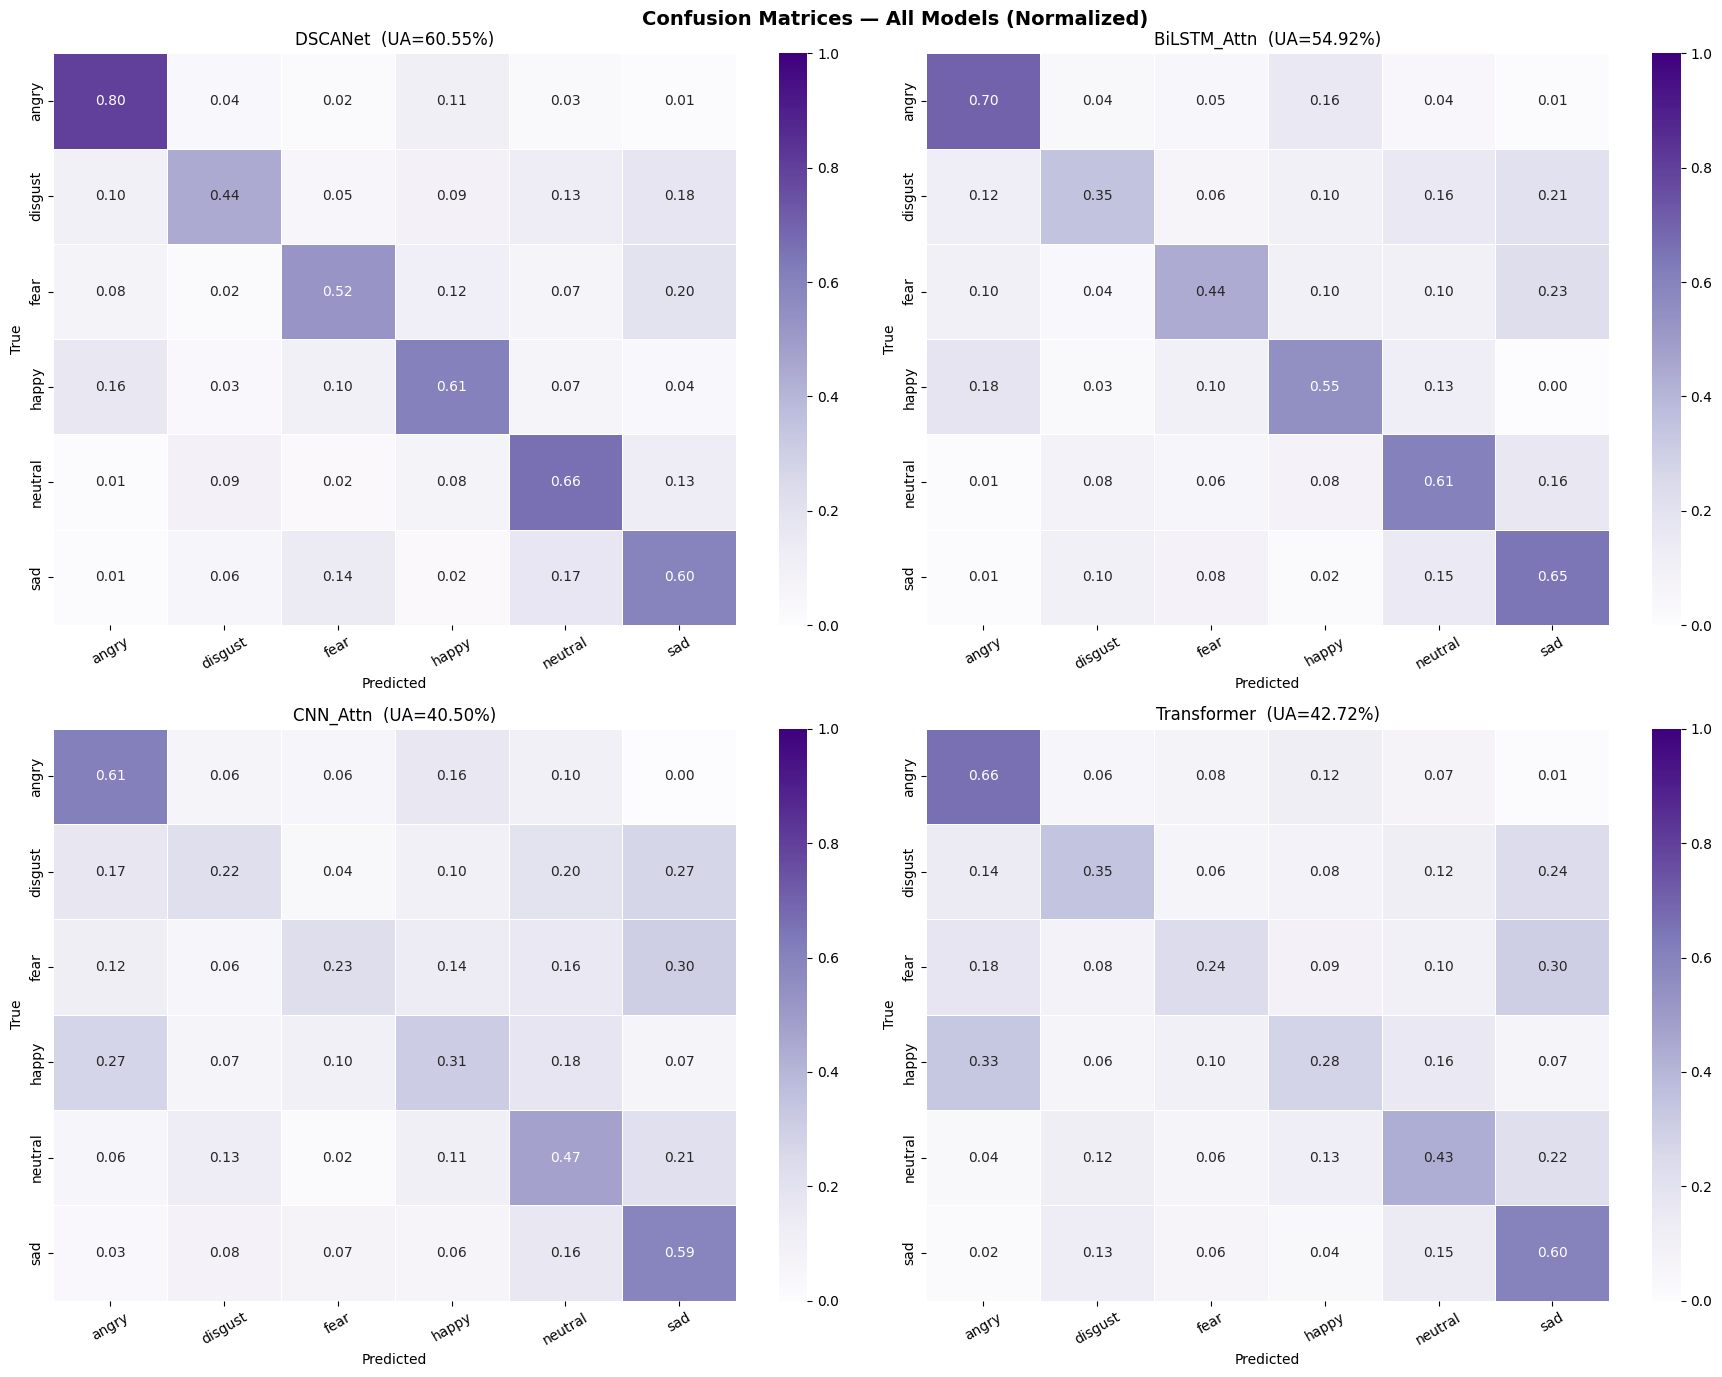

In [26]:
# Confusion matrices for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Confusion Matrices — All Models (Normalized)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, r) in enumerate(all_test_results.items()):
    cm = confusion_matrix(r['labels'], r['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Purples',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[i], linewidths=0.5, linecolor='white', vmin=0, vmax=1)
    axes[i].set_title(f'{name}  (UA={r["ua"]:.2%})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# DS-CANet ablation (proves cross-attention contribution)
class DSCANet_NoCrossAttn(nn.Module):
    """Same as DSCANet but cross-attention replaced with naive concatenation."""
    def __init__(self, spectral_dim, temporal_dim, d_model=64,
                 num_heads=4, num_classes=6, dropout=0.5,
                 lstm_hidden=64, lstm_layers=2, temporal_steps=10):
        super().__init__()
        self.spec_proj = nn.Sequential(
            nn.Linear(spectral_dim, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.spec_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.spec_norm = nn.LayerNorm(d_model)
        assert temporal_dim % temporal_steps == 0
        step_dim = temporal_dim // temporal_steps
        self.step_proj = nn.Linear(step_dim, lstm_hidden)
        self.bilstm    = nn.LSTM(lstm_hidden, lstm_hidden, lstm_layers,
                                 batch_first=True, bidirectional=True,
                                 dropout=dropout if lstm_layers>1 else 0)
        self.lstm_proj = nn.Sequential(
            nn.Linear(2*lstm_hidden, d_model), nn.LayerNorm(d_model), nn.GELU())
        self.temp_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.temp_norm = nn.LayerNorm(d_model)
        self.temporal_steps = temporal_steps
        self.pool_a    = EmotionAwarePooling(d_model)
        self.pool_b    = EmotionAwarePooling(d_model)
        self.drop      = nn.Dropout(dropout)
        # Naive concat fusion instead of cross-attention
        self.fusion    = nn.Sequential(nn.Linear(d_model*2, d_model), nn.LayerNorm(d_model))
        self.head      = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, num_classes))

    def forward(self, x_spec, x_temp):
        a = self.spec_proj(x_spec).unsqueeze(1)
        ao, _ = self.spec_attn(a, a, a)
        a = self.spec_norm(a + self.drop(ao))
        B = x_temp.size(0)
        b = x_temp.view(B, self.temporal_steps, -1)
        b = self.step_proj(b)
        b, _ = self.bilstm(b)
        b = self.lstm_proj(b)
        bo, _ = self.temp_attn(b, b, b)
        b = self.temp_norm(b + self.drop(bo))
        a = self.pool_a(a)
        b = self.pool_b(b)
        fused = self.fusion(torch.cat([a, b], dim=-1))
        return self.head(fused)


abl_model = DSCANet_NoCrossAttn(
    spectral_dim=SPECTRAL_DIM, temporal_dim=TEMPORAL_DIM,
    d_model=D_MODEL, num_heads=NUM_HEADS, num_classes=NUM_CLASSES,
    dropout=DROPOUT, lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS,
    temporal_steps=10).to(DEVICE)

abl_model, abl_val_ua, _ = train_model(abl_model, 'DSCANet_NoCrossAttn')
_, abl_wa, abl_ua, _, _  = evaluate(abl_model, test_loader, criterion, DEVICE)

dsca_wa = all_test_results['DSCANet']['wa']
dsca_ua = all_test_results['DSCANet']['ua']

print('\n' + '='*55)
print('         ABLATION: CROSS-ATTENTION CONTRIBUTION')
print('='*55)
print(f'  {"DS-CANet (full)":<28} WA={dsca_wa:.2%}  UA={dsca_ua:.2%}')
print(f'  {"DS-CANet w/o cross-attn":<28} WA={abl_wa:.2%}  UA={abl_ua:.2%}')
print('─'*55)
print(f'  {"Gain from cross-attention":<28} WA={dsca_wa-abl_wa:+.2%}  UA={dsca_ua-abl_ua:+.2%}')
print('='*55)


──────────────────────────────────────────────────────────────────────
Training: DSCANet_NoCrossAttn
──────────────────────────────────────────────────────────────────────
  Ep |   TrLoss |   TrAcc |   VaLoss |    VaWA |    VaUA |    Gap
────────────────────────────────────────────────────────────
   1 |   1.3773 | 18.23% |   1.2082 | 24.35% | 24.29% | -6.1%
     ↑ New best UA: 24.29%
   2 |   1.3898 | 22.63% |   1.1335 | 31.99% | 31.99% | -9.4%
     ↑ New best UA: 31.99%
   3 |   1.3262 | 27.11% |   1.0673 | 36.75% | 36.77% | -9.6%
     ↑ New best UA: 36.77%
   4 |   1.2662 | 31.07% |   1.0027 | 39.37% | 39.37% | -8.3%
     ↑ New best UA: 39.37%
   5 |   1.2252 | 33.34% |   0.9655 | 41.31% | 41.32% | -8.0%
     ↑ New best UA: 41.32%
   6 |   1.1893 | 35.18% |   0.9306 | 42.39% | 42.38% | -7.2%
     ↑ New best UA: 42.38%
   7 |   1.1237 | 37.71% |   0.9120 | 43.93% | 43.93% | -6.2%
     ↑ New best UA: 43.93%
   8 |   1.1089 | 38.25% |   0.9007 | 44.74% | 44.74% | -6.5%
     ↑ New best

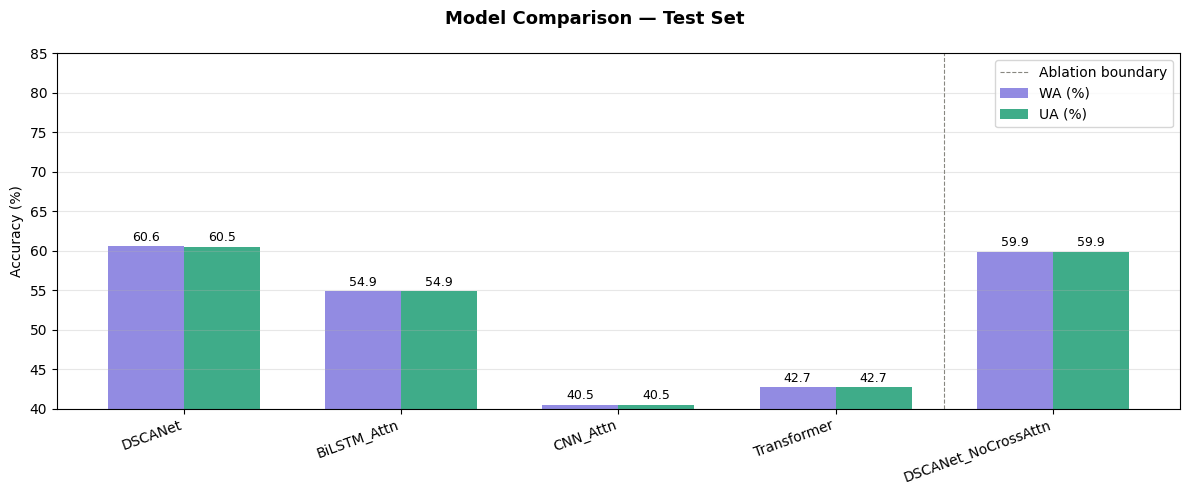

In [28]:
# Final comparison bar chart
model_names = list(all_test_results.keys()) + ['DSCANet_NoCrossAttn']
uas = [all_test_results[n]['ua'] for n in all_test_results] + [abl_ua]
was = [all_test_results[n]['wa'] for n in all_test_results] + [abl_wa]

x   = np.arange(len(model_names))
w   = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Model Comparison — Test Set', fontsize=13, fontweight='bold')

bars_wa = ax.bar(x - w/2, [v*100 for v in was], w, label='WA (%)', color='#7F77DD', alpha=0.85)
bars_ua = ax.bar(x + w/2, [v*100 for v in uas], w, label='UA (%)', color='#1D9E75', alpha=0.85)

for bar in bars_wa:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars_ua:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.axvline(x=3.5, color='#888780', linestyle='--', linewidth=0.8, label='Ablation boundary')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(40, 85)
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Save everything 

# Save all model weights
for name, model in trained_models.items():
    torch.save(model.state_dict(), OUTPUT_DIR / f'{name}_final.pt')

# Save full results as JSON
results_summary = {
    name: {
        'test_wa': round(r['wa'], 4),
        'test_ua': round(r['ua'], 4),
        'per_class': {k: round(float(v), 4) for k, v in r['per'].items()}
    }
    for name, r in all_test_results.items()
}
results_summary['DSCANet_NoCrossAttn'] = {
    'test_wa': round(abl_wa, 4),
    'test_ua': round(abl_ua, 4),
}
results_summary['cross_attn_gain_ua'] = round(dsca_ua - abl_ua, 4)
results_summary['best_model']         = best_name
results_summary['label_to_int']       = label_to_int
results_summary['int_to_label']       = {str(k): v for k, v in int_to_label.items()}
results_summary['hyperparams'] = {
    'd_model': D_MODEL, 'num_heads': NUM_HEADS, 'dropout': DROPOUT,
    'lstm_hidden': LSTM_HIDDEN, 'lr': LR, 'spectral_dim': SPECTRAL_DIM,
    'temporal_dim': TEMPORAL_DIM, 'feature_dim': FEATURE_DIM
}

with open(OUTPUT_DIR / 'all_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Saved to Drive:')
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size / 1024
    print(f'  {f.name:<40} ({size:.0f} KB)')

print(f'\nBest model: {best_name} (UA={best_val_uas[best_name]:.2%})')

Saved to Drive:
  BiLSTM_Attn_best.pt                      (768 KB)
  BiLSTM_Attn_final.pt                     (768 KB)
  CNN_Attn_best.pt                         (178 KB)
  CNN_Attn_final.pt                        (178 KB)
  DSCANet_NoCrossAttn_best.pt              (907 KB)
  DSCANet_best.pt                          (1176 KB)
  DSCANet_final.pt                         (1176 KB)
  Transformer_best.pt                      (615 KB)
  Transformer_final.pt                     (615 KB)
  all_confusion_matrices.png               (277 KB)
  all_models_curves.png                    (225 KB)
  all_results.json                         (1 KB)
  model_comparison.png                     (72 KB)
  scaler.pkl                               (9 KB)

Best model: DSCANet (UA=59.09%)
